# ***EstateMate*** : AI-Powered Real Estate Valuation DSS

## Artificial Intelligence for Business Decisions nd Transformation

## Team Members
- Eris Leksi  
- Mandeep Singh Brar  
- Reham Abuarqoub 
- Yu-Chen Chou  
- Erica Holden

---

## Project Overview
- Build a **Decision Support System (DSS)** for **real estate property valuation**  
- Inspired by Zillow’s Zestimate model  
- Provides **data-driven, fair, and transparent pricing**  

---

## Objectives
- Deliver **accurate property valuations** using AI models  
- Support **buyers, sellers, agents, banks, and regulators** in decision-making  
- Enhance **trust, transparency, and efficiency** in the housing market   

## Dataset
Link: https://www.kaggle.com/datasets/paultimothymooney/zillow-house-price-data?utm_source=chatgpt.com

Content: Data about housing prices and rental prices broken down according to city and state and number of bedrooms. More detail can be found at https://www.zillow.com/research/data/ and at https://www.zillow.com/research/home-sales-methodology-7733/.

Acknowledgements: The data was downloaded from https://www.zillow.com/research/data/. Banner photo from Ian Keefe on Unsplash. Dataset license described at https://www.zillow.com/research/data/.

## 0. Importing the necessary libraries

In [27]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 1. Loading the datasets

In [10]:
df = pd.read_csv('./data/Housing.csv')

print("Dataset loaded successfully! ")

Dataset loaded successfully! 


## 2. EDA

### 2.1. Basic EDA about the dataset

In [13]:
print(df.shape)
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.info())
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.describe())
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.isnull().sum())

(545, 13)
------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usag


We start by loading the dataset and checking its size, structure, and basic statistics.  
This helps us understand how many features we have, their data types, and whether any values are missing.


### 2.2. Target Variable (Price) Distribution

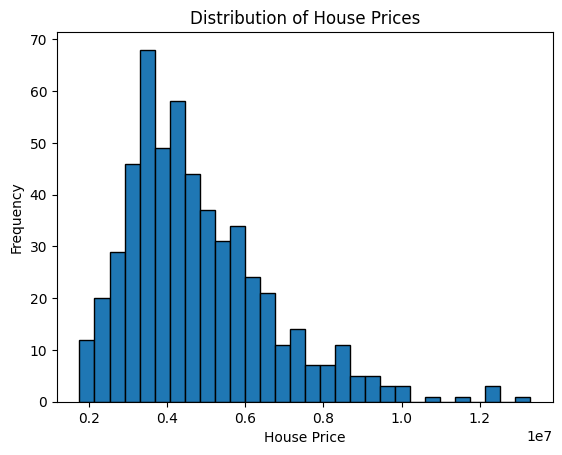

In [15]:
plt.hist(df["price"], bins=30, edgecolor="k")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


We visualize the distribution of house prices to check if the data is skewed, normally distributed, or has extreme values.


### 2.3. Correlations (Numerical Features Only)

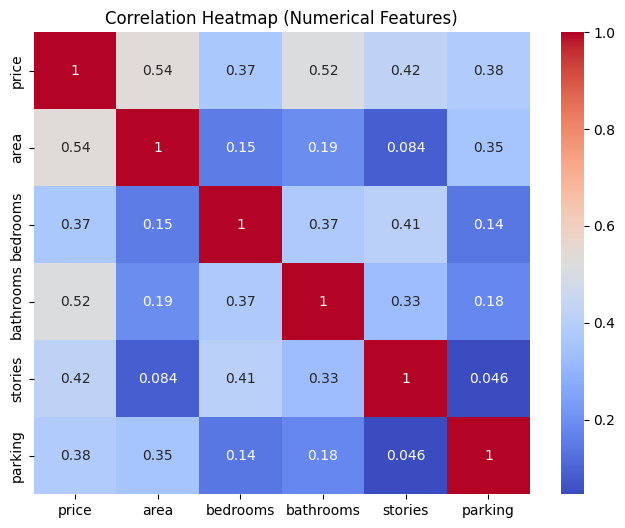

In [16]:
numeric_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()



We calculate correlations between numerical features and house price.  
This helps us identify which features (like area, bedrooms, or parking) are most strongly related to price.


### 2.4. Price vs. Numerical Features

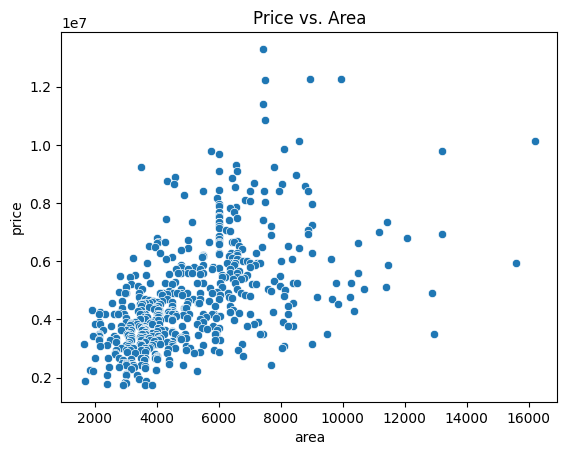

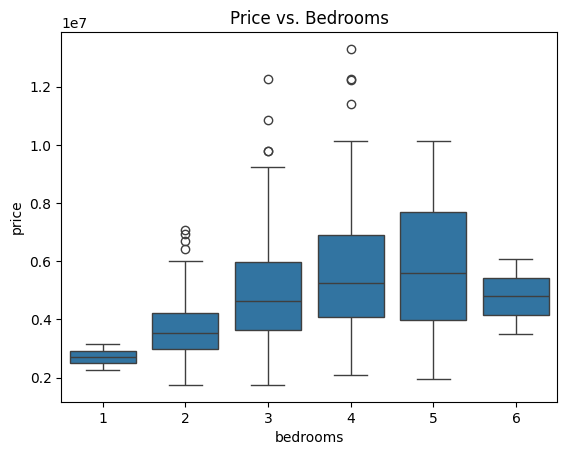

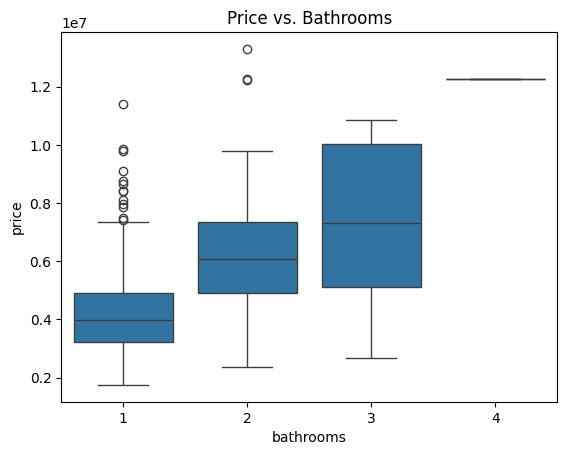

In [17]:
sns.scatterplot(data=df, x="area", y="price")
plt.title("Price vs. Area")
plt.show()

sns.boxplot(data=df, x="bedrooms", y="price")
plt.title("Price vs. Bedrooms")
plt.show()

sns.boxplot(data=df, x="bathrooms", y="price")
plt.title("Price vs. Bathrooms")
plt.show()


We use scatterplots and boxplots to examine the relationship between house price and numerical features such as area, bedrooms, and bathrooms.  
This shows how price changes with each of these variables.


### 2.5. Price vs. Categorical Features

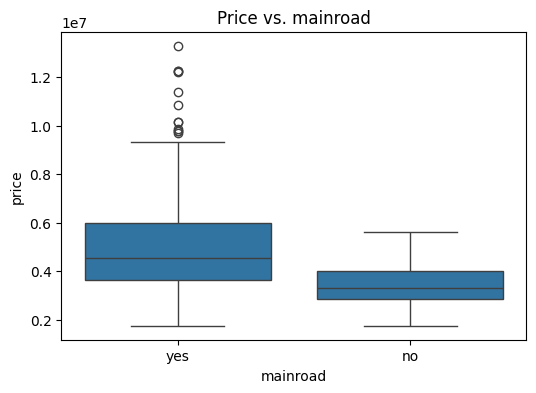

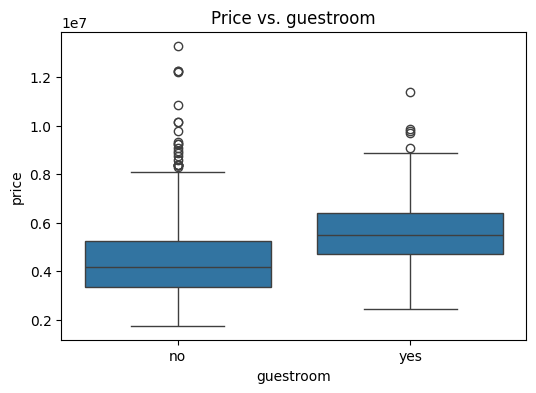

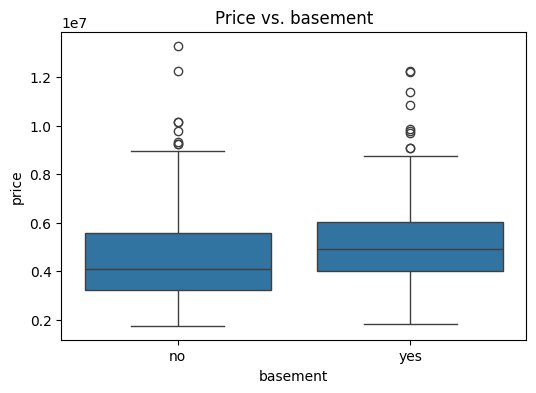

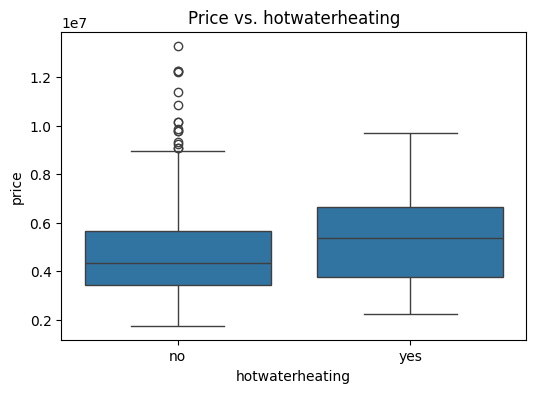

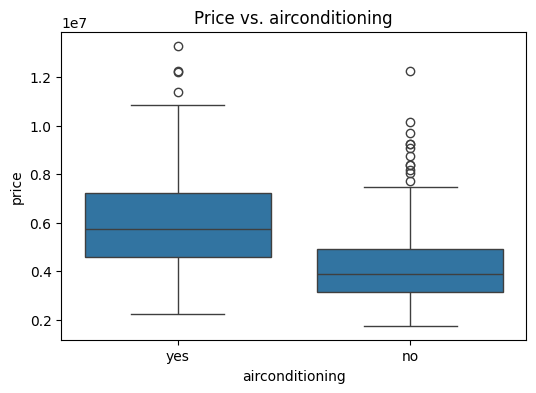

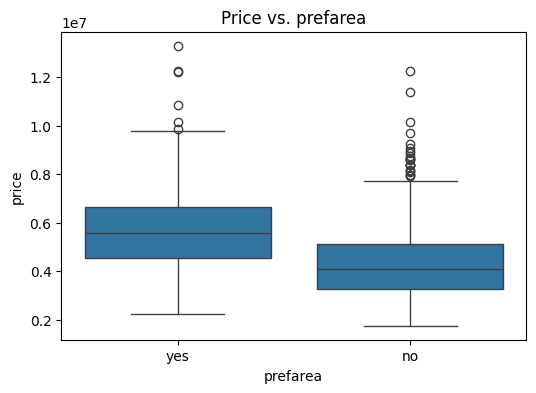

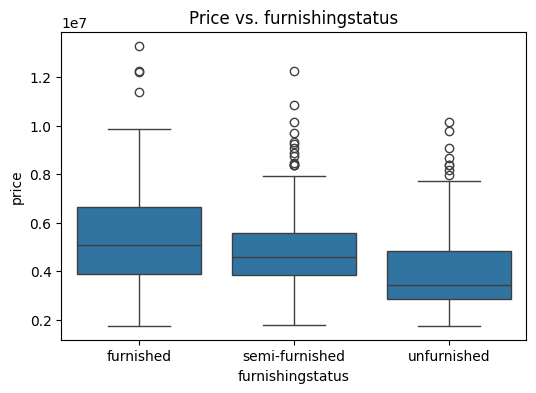

In [18]:
categorical_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
                    "airconditioning", "prefarea", "furnishingstatus"]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col, y="price")
    plt.title(f"Price vs. {col}")
    plt.show()


We compare house prices across categories (main road, guestroom, basement, etc.) using boxplots.  
This reveals how different amenities and conditions affect house prices.


### 2.6. Outlier Detection (Boxplots)

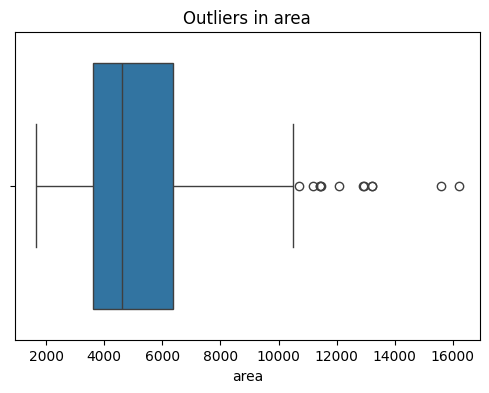

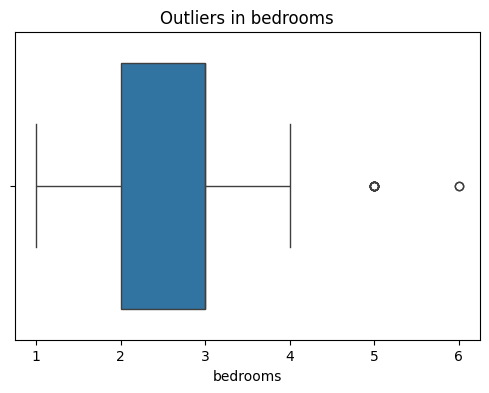

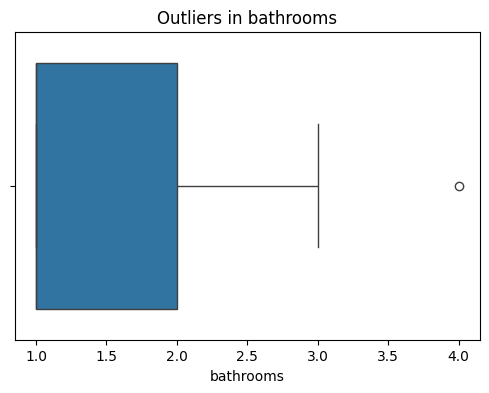

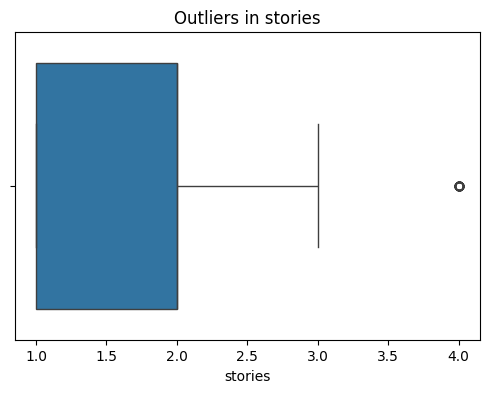

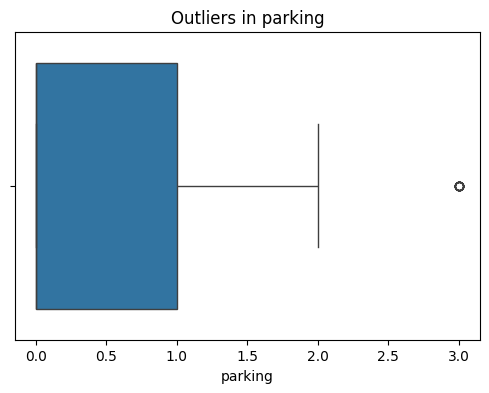

In [19]:
for col in ["area", "bedrooms", "bathrooms", "stories", "parking"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


We use boxplots to detect potential outliers in numerical features (like unusually high values for area or price).  
Outliers can heavily influence predictive models, so spotting them is important before training.


## 3. Preprocessing

In [22]:
# Encode categorical variables (yes/no → 0/1, furnishingstatus → one-hot)
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

# First split: Train (80%) + Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Validation (10%) + Test (10%)
# 10% out of total = 10/20 = 0.5 of the temp set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features (fit on train only, transform all sets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Confirmation
print("Preprocessing complete.")
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Preprocessing complete.
Training set shape: (436, 13)
Validation set shape: (54, 13)
Test set shape: (55, 13)


In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=200)
}

results = {}

for name, model in models.items():
    # Train on training set
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_scaled)
    
    # Metrics
    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

# Display results
results_df = pd.DataFrame(results).T.sort_values(by="RMSE")
print("Validation Results:\n")
print(results_df)

# Select best model (lowest RMSE)
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")

Validation Results:

                             MAE          RMSE        R²
Linear Regression  917947.527167  1.305190e+06  0.634422
Random Forest      943633.081636  1.399821e+06  0.579490
Gradient Boosting  940141.230310  1.461783e+06  0.541438

Best Model: Linear Regression


Test Set Results:
MAE: 1021192.08
RMSE: 1343202.06
R²: 0.6679


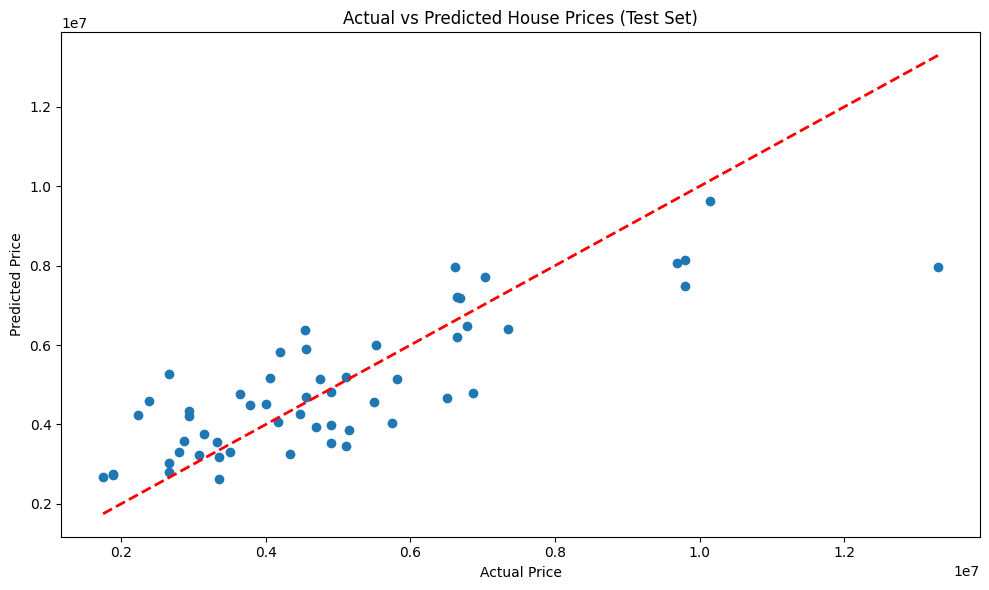

In [30]:
# Test the best model on test set
y_test_pred = best_model.predict(X_test_scaled)

# Calculate metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Display results
print("Test Set Results:")
print(f"MAE: {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²: {test_r2:.4f}")

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Test Set)")
plt.tight_layout()
plt.show()